# LLM-powered Financial Fraud Detection System

# Dataset Summary — Credit Card Fraud Detection

# About the Dataset
This dataset contains **284,807 real credit card transactions** made by 
European cardholders over **2 days in September 2013**. It was collected 
and shared by the Machine Learning Group at Université Libre de Bruxelles 
(ULB) for fraud detection research.

# Goal
Build a machine learning model that can automatically detect fraudulent 
transactions in real-time — flagging suspicious activity before the bank 
loses money.

# Class Distribution
- **284,315 transactions** are legitimate (Class = 0) — 99.827%
- **492 transactions** are fraudulent (Class = 1) — 0.173%
- This is a **severely imbalanced dataset** — fraud is extremely rare

# Column Descriptions

| Column | Type | Description |
|--------|------|-------------|
| Time | Numerical | Seconds elapsed since the first transaction in the dataset |
| V1–V28 | Numerical | **PCA-transformed features** — original features were anonymized by the bank for privacy and legal compliance. Cannot be reverse-engineered. |
| Amount | Numerical | Transaction amount in Euros — this is a real, untransformed value |
| Class | Binary | **Target variable** — 0 = Legitimate, 1 = Fraud |

# Why V1–V28 Cannot Be Named
The bank applied **PCA (Principal Component Analysis)** to the original 
28 features before releasing the dataset. This was done for two reasons:

1. **Privacy law** — GDPR prohibits sharing identifiable customer data publicly
2. **Security** — exposing real feature names would help fraudsters 
   reverse-engineer the detection system

Despite anonymization, the mathematical fraud patterns are fully preserved. 
The model learns from these patterns just as effectively as it would 
from named features.

# Key Challenges
1. **Class imbalance** — 99.83% legitimate vs 0.17% fraud makes accuracy 
   a useless metric. We use F1 Score instead.
2. **No feature names** — V1–V28 are anonymous. SHAP explainability helps 
   us understand which features matter most.
3. **Real-world complexity** — Fraud patterns are subtle and overlap 
   with legitimate transactions.

# What This Dataset Represents in Production
In real banks, data scientists never see raw customer data. They always 
work with anonymized or encrypted features — exactly like V1–V28 here. 
This dataset accurately mirrors real production fraud detection workflows 
at financial institutions like JP Morgan, Goldman Sachs, and Capital One.

# Solution Approach
1. **XGBoost classifier** —  a strong candidate model for imbalanced tabular data
2. **SMOTE or class-weighting** — handle class imbalance on training data only
3. **SHAP explainability** — explain WHY each transaction was flagged
4. **LangChain RAG pipeline** — retrieve relevant FATF/FinCEN regulations 
   for each fraud flag
5. **FastAPI + Streamlit** — deploy as a production web application

In [1]:
from pathlib import Path
import subprocess
import sys

DATASET = "mlg-ulb/creditcardfraud"
DATA_DIR = Path("data/raw")
CSV_FILE = DATA_DIR / "creditcard.csv"


def download_dataset():
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    if CSV_FILE.exists():
        print(f"Dataset already exists: {CSV_FILE}")
        return

    print("Dataset not found. Downloading from Kaggle...")

    try:
        subprocess.run(
            [
                sys.executable,
                "-m",
                "kaggle",
                "datasets",
                "download",
                "-d",
                DATASET,
                "-p",
                str(DATA_DIR),
                "--unzip",
            ],
            check=True,
        )
    except subprocess.CalledProcessError:
        raise RuntimeError(
            "\nKaggle download failed.\n\n"
            "Please check the following:\n"
            "1. Install Kaggle: pip install kaggle\n"
            "2. Place kaggle.json in the correct folder:\n"
            "   Windows: C:/Users/<your-username>/.kaggle/kaggle.json\n"
            "   Mac/Linux: ~/.kaggle/kaggle.json\n"
            "3. Make sure you accepted the dataset terms on Kaggle.\n"
        )

    if not CSV_FILE.exists():
        raise FileNotFoundError(
            "Download finished, but creditcard.csv was not found in data/raw."
        )

    print("Dataset downloaded successfully.")
    print(f"Saved to: {CSV_FILE}")


if __name__ == "__main__":
    download_dataset()

Dataset already exists: data\raw\creditcard.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/raw/creditcard.csv")
print(f"Dataset Loaded Successfully")
print(f"Shape: {df.shape}")
df_raw = df.copy()
df.head()




Dataset Loaded Successfully
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(f"Total Columns: {df.shape[1]}")
print("All Columns:")
print(df.columns.tolist())


Total Columns: 31
All Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [4]:
print(df[['Time', 'Amount', 'Class']].describe())

                Time         Amount          Class
count  284807.000000  284807.000000  284807.000000
mean    94813.859575      88.349619       0.001727
std     47488.145955     250.120109       0.041527
min         0.000000       0.000000       0.000000
25%     54201.500000       5.600000       0.000000
50%     84692.000000      22.000000       0.000000
75%    139320.500000      77.165000       0.000000
max    172792.000000   25691.160000       1.000000


In [5]:
print(f"Fraud: {df['Class'].sum()} Fraud Transactions")
print(f"Legitimate: {(df['Class']==0).sum()} Legitimate Transactions")
print(f"Fraud rate: {df['Class'].mean()*100:.3f}%")

print("Unique target values:", df['Class'].unique())
print("Number of target classes:", df['Class'].nunique())


Fraud: 492 Fraud Transactions
Legitimate: 284315 Legitimate Transactions
Fraud rate: 0.173%
Unique target values: [0 1]
Number of target classes: 2


In [6]:
from IPython.display import display

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum().to_string())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nClass Distribution:")
print(df['Class'].value_counts())

print("\nClass Distribution Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Dataset Shape:
(284807, 31)

First 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0

Total Missing Values:
0

Duplicate Rows:
1081

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Distribution Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


# Data Quality Checks and Cleaning

In [7]:
# =========================
# Data Cleaning
# =========================

# Reset from backup — makes this cell safe to re-run
df = df_raw.copy()

print("Original dataset shape:", df.shape)

# --------------------------------------------------
# 1. Investigate fraud duplicates before dropping
# --------------------------------------------------
fraud_dupes = df[df.duplicated(keep=False) & (df['Class'] == 1)]
print(f"\nFraud transactions flagged as duplicates: {len(fraud_dupes)}")
print("Fraud duplicate rows (identical Time = true data-entry duplicate, safe to drop):")
print(fraud_dupes[['Time', 'Amount', 'Class']].sort_values('Time').head(10).to_string())

# --------------------------------------------------
# 2. Remove duplicate rows
# --------------------------------------------------
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows before cleaning: {duplicate_count}")
print("\nDuplicate rows by class:")
print(df[df.duplicated()]['Class'].value_counts())

df = df.drop_duplicates().reset_index(drop=True)

print(f"\nDuplicate rows after cleaning: {df.duplicated().sum()}")
print("Dataset shape after removing duplicates:", df.shape)

print("\nClass distribution after duplicate removal:")
print(df['Class'].value_counts())
print("\nClass distribution percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

# --------------------------------------------------
# 3. Missing values
# --------------------------------------------------
missing_values = df.isnull().sum()
print("\nTotal missing values:", missing_values.sum())
if missing_values.sum() == 0:
    print("No missing values found.")
else:
    print(missing_values[missing_values > 0])

# --------------------------------------------------
# 4. Validate target column
# df.info() confirms Class is already int64 — no cast needed
# --------------------------------------------------
print("\nUnique target values:", df['Class'].unique())
print("Target dtype:", df['Class'].dtype)

# --------------------------------------------------
# 5. Check for invalid negative values
# --------------------------------------------------
print("\nNegative Amount values:", (df['Amount'] < 0).sum())
print("Negative Time values:", (df['Time'] < 0).sum())

# --------------------------------------------------
# 6. Infinite values in raw data
# --------------------------------------------------
numeric_df = df.select_dtypes(include=['number'])
print("\nInfinite values in raw dataset:", np.isinf(numeric_df).sum().sum())

# --------------------------------------------------
# 7. Non-numeric columns
# --------------------------------------------------
non_numeric_cols = df.select_dtypes(exclude=['number']).columns.tolist()
print("\nNon-numeric columns:", non_numeric_cols)

# --------------------------------------------------
# 8. Zero amount analysis
# Zero-amount transactions are a known fraud vector (card authorization testing)
# --------------------------------------------------
zero_amount = df[df['Amount'] == 0]
baseline_rate = df['Class'].mean() * 100
zero_rate = zero_amount['Class'].mean() * 100

print(f"\nZero amount transactions: {len(zero_amount)}")
print("\nZero amount class distribution:")
print(zero_amount['Class'].value_counts())
print(f"\nBaseline fraud rate:     {baseline_rate:.3f}%")
print(f"Zero-amount fraud rate:  {zero_rate:.3f}%")
print(f"Zero-amount is {zero_rate / baseline_rate:.1f}x more likely to be fraud than baseline")

print("\nCleaned dataset shape:", df.shape)


Original dataset shape: (284807, 31)

Fraud transactions flagged as duplicates: 32
Fraud duplicate rows (identical Time = true data-entry duplicate, safe to drop):
           Time  Amount  Class
102441  68207.0    1.00      1
102442  68207.0    1.00      1
102443  68207.0    1.00      1
102444  68207.0    1.00      1
102445  68207.0    1.00      1
102446  68207.0    1.00      1
141257  84204.0    0.00      1
141258  84204.0    0.00      1
141259  84204.0  512.25      1
141260  84204.0  512.25      1

Duplicate rows before cleaning: 1081

Duplicate rows by class:
Class
0    1062
1      19
Name: count, dtype: int64

Duplicate rows after cleaning: 0
Dataset shape after removing duplicates: (283726, 31)

Class distribution after duplicate removal:
Class
0    283253
1       473
Name: count, dtype: int64

Class distribution percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

Total missing values: 0
No missing values found.

Unique target values: [0 1]
Target dtype

# Outlier Investigation — V1-V28 Extreme Values

In [8]:
# =========================
# Outlier Investigation — V1-V28 Extreme Values
# =========================
from IPython.display import display

# Columns with extreme sigma values identified from describe() analysis:
# V7 (~97σ), V5 (~82σ), V23 (~72σ), V8 (~61σ), V2 (~44σ), V3 (~32σ), V1 (~29σ)
outlier_cols = ['V1', 'V2', 'V3', 'V5', 'V7', 'V8', 'V23']

baseline_fraud_rate = df['Class'].mean()
print(f"Baseline fraud rate: {baseline_fraud_rate * 100:.3f}%")

# Store thresholds to reuse in flag creation — avoids recalculation
thresholds = {}

for col in outlier_cols:
    print("\n" + "=" * 55)
    print(f"  Outlier Analysis — {col}")
    print("=" * 55)

    mean = df[col].mean()
    std  = df[col].std()
    lower_10sigma = mean - 10 * std
    upper_10sigma = mean + 10 * std

    thresholds[col] = (lower_10sigma, upper_10sigma)

    extreme_mask = (df[col] < lower_10sigma) | (df[col] > upper_10sigma)
    extreme_data = df[extreme_mask]

    print(f"  Mean: {mean:.4f}  |  Std: {std:.4f}")
    print(f"  10-sigma range: [{lower_10sigma:.2f}, {upper_10sigma:.2f}]")
    print(f"  Extreme rows found: {extreme_data.shape[0]}")

    if extreme_data.shape[0] > 0:
        print("\n  Class distribution among extreme values:")
        print(extreme_data['Class'].value_counts().to_string())

        extreme_fraud_rate = extreme_data['Class'].mean()
        print(f"\n  Extreme {col} fraud rate:         {extreme_fraud_rate * 100:.3f}%")
        print(f"  Fraud risk multiplier vs baseline: {extreme_fraud_rate / baseline_fraud_rate:.1f}x")

        print(f"\n  Top 10 most extreme rows:")
        display(
            extreme_data[['Time', 'Amount', col, 'Class']]
            .sort_values(col)
            .head(10)
        )

# --------------------------------------------------
# Outlier Flag Features
# Safer than deletion — gives the model an explicit signal that a value is extreme
# Deterministic transforms so no data leakage risk
# --------------------------------------------------
print("\n" + "=" * 55)
print("  Creating Outlier Flag Features")
print("=" * 55)

for col in outlier_cols:
    lower, upper = thresholds[col]
    df[f'{col}_ExtremeFlag'] = (
        (df[col] < lower) | (df[col] > upper)
    ).astype(int)
    flag_count = df[f'{col}_ExtremeFlag'].sum()
    print(f"  {col}_ExtremeFlag: {flag_count} extreme transactions flagged")

flag_cols = [f'{col}_ExtremeFlag' for col in outlier_cols]
print("\nCreated outlier flag features:", flag_cols)
print("Dataset shape after adding flags:", df.shape)

df[flag_cols + ['Class']].tail()


Baseline fraud rate: 0.167%

  Outlier Analysis — V1
  Mean: 0.0059  |  Std: 1.9480
  10-sigma range: [-19.47, 19.49]
  Extreme rows found: 164

  Class distribution among extreme values:
Class
0    140
1     24

  Extreme V1 fraud rate:         14.634%
  Fraud risk multiplier vs baseline: 87.8x

  Top 10 most extreme rows:


,Time,Amount,V1,Class
39590,39954.0,1201.83,-56.407510,0
219428,142071.0,303.80,-46.855047,0
223742,143863.0,200.00,-41.928738,0
233649,148008.0,157.43,-40.470142,0
205521,136137.0,1676.60,-40.042537,0
219306,142019.0,5964.95,-37.558067,0
205494,136124.0,1676.60,-37.054295,0
58220,48401.0,19656.53,-36.802320,0
144470,86570.0,102.00,-36.510583,0
230599,146772.0,3552.96,-35.905105,0



  Outlier Analysis — V2
  Mean: -0.0041  |  Std: 1.6467
  10-sigma range: [-16.47, 16.46]
  Extreme rows found: 241

  Class distribution among extreme values:
Class
0    235
1      6

  Extreme V2 fraud rate:         2.490%
  Fraud risk multiplier vs baseline: 14.9x

  Top 10 most extreme rows:


,Time,Amount,V2,Class
39590,39954.0,1201.83,-72.715728,0
58220,48401.0,19656.53,-63.344698,0
150705,95286.0,18910.00,-60.464618,0
227878,145630.0,7367.00,-50.383269,0
228191,145773.0,1210.00,-48.060856,0
235555,148806.0,152.00,-47.429676,0
219428,142071.0,303.80,-45.607973,0
130647,79508.0,370.90,-44.639245,0
46641,42951.0,12910.93,-42.172688,0
15311,26752.0,2520.00,-40.978852,0



  Outlier Analysis — V3
  Mean: 0.0016  |  Std: 1.5087
  10-sigma range: [-15.09, 15.09]
  Extreme rows found: 97

  Class distribution among extreme values:
Class
1    60
0    37

  Extreme V3 fraud rate:         61.856%
  Fraud risk multiplier vs baseline: 371.0x

  Top 10 most extreme rows:


...

,Time,Amount,V8,Class
65163,51575.0,500.00,-73.216718,0
137702,82543.0,203.50,-50.943369,0
138183,82802.0,305.25,-50.688419,0
138692,83065.0,407.00,-50.420090,0
18570,29650.0,6.28,-41.484823,0
154090,102572.0,0.01,-41.044261,1
209765,138013.0,328.32,-39.688571,0
255128,157529.0,1.00,-39.267378,0
153993,102114.0,0.00,-38.987263,1
255169,157547.0,7.27,-38.751525,0



  Outlier Analysis — V23
  Mean: 0.0002  |  Std: 0.6237
  10-sigma range: [-6.24, 6.24]
  Extreme rows found: 381

  Class distribution among extreme values:
Class
0    379
1      2

  Extreme V23 fraud rate:         0.525%
  Fraud risk multiplier vs baseline: 3.1x

  Top 10 most extreme rows:


,Time,Amount,V23,Class
91575,63675.0,6000.00,-44.807735,0
233034,147747.0,12.31,-36.666000,0
227081,145283.0,10000.00,-32.828995,0
225850,144755.0,8360.00,-30.269720,0
219428,142071.0,303.80,-27.533643,0
186041,127224.0,3804.63,-27.215436,0
15115,26525.0,8.94,-26.751119,0
175668,122723.0,1676.60,-26.429741,0
63291,50770.0,37.16,-25.356744,0
221497,142920.0,880.18,-23.222016,0



  Creating Outlier Flag Features
  V1_ExtremeFlag: 164 extreme transactions flagged
  V2_ExtremeFlag: 241 extreme transactions flagged
  V3_ExtremeFlag: 97 extreme transactions flagged
  V5_ExtremeFlag: 178 extreme transactions flagged
  V7_ExtremeFlag: 259 extreme transactions flagged
  V8_ExtremeFlag: 408 extreme transactions flagged
  V23_ExtremeFlag: 381 extreme transactions flagged

Created outlier flag features: ['V1_ExtremeFlag', 'V2_ExtremeFlag', 'V3_ExtremeFlag', 'V5_ExtremeFlag', 'V7_ExtremeFlag', 'V8_ExtremeFlag', 'V23_ExtremeFlag']
Dataset shape after adding flags: (283726, 38)


,V1_ExtremeFlag,V2_ExtremeFlag,V3_ExtremeFlag,V5_ExtremeFlag,V7_ExtremeFlag,V8_ExtremeFlag,V23_ExtremeFlag,Class
283721,0,0,0,0,0,0,0,0
283722,0,0,0,0,0,0,0,0
283723,0,0,0,0,0,0,0,0
283724,0,0,0,0,0,0,0,0
283725,0,0,0,0,0,0,0,0


# Feature Engineering

In [9]:
# =========================
# Feature Engineering
# =========================

print("Shape before feature engineering:", df.shape)

# --------------------------------------------------
# 1. Log-transform Amount
# Reduces right skew; log1p handles Amount=0 safely via log(1 + x)
# --------------------------------------------------
df['LogAmount'] = np.log1p(df['Amount'])

# --------------------------------------------------
# 2. Zero-amount flag
# Zero-amount transactions are ~8x more likely to be fraud (card authorization testing)
# --------------------------------------------------
df['IsZeroAmount'] = (df['Amount'] == 0).astype(int)

# --------------------------------------------------
# 3. Time decomposition
# --------------------------------------------------
df['Hour']      = (df['Time'] / 3600).astype(int)    # absolute hour 0-47 across 2-day dataset
df['HourOfDay'] = df['Hour'] % 24                    # 0-23 daily cycle
df['Day']       = (df['Time'] // 86400).astype(int)  # 0 = Day 1, 1 = Day 2

# --------------------------------------------------
# 4. Cyclic encoding of hour
# sin/cos captures that hour 23 and hour 0 are adjacent — raw integer does not
# --------------------------------------------------
df['HourSin'] = np.sin(2 * np.pi * df['HourOfDay'] / 24)
df['HourCos'] = np.cos(2 * np.pi * df['HourOfDay'] / 24)

# Note: RobustScaler for Amount will be applied AFTER train-test split
# to avoid data leakage — fit on X_train only, then transform X_test

# --------------------------------------------------
# 5. Fraud rate by Day — verify if fraud pattern differs between Day 1 and Day 2
# --------------------------------------------------
print("\nFraud rate by Day of dataset:")
print(df.groupby('Day')['Class'].mean().mul(100).round(3).to_string())

# --------------------------------------------------
# 6. Final validation
# --------------------------------------------------
numeric_df = df.select_dtypes(include=['number'])
print("\nInfinite values after feature engineering:", np.isinf(numeric_df).sum().sum())
print("NaN values after feature engineering:     ", numeric_df.isnull().sum().sum())

constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("\nConstant columns:", constant_cols)

engineered = ['LogAmount', 'IsZeroAmount', 'Hour', 'HourOfDay', 'Day', 'HourSin', 'HourCos']
print("\nEngineered columns added:", engineered)
print("Final dataset shape:", df.shape)

df.head()


Shape before feature engineering: (283726, 38)

Fraud rate by Day of dataset:
Day
0    0.189
1    0.144

Infinite values after feature engineering: 0
NaN values after feature engineering:      0

Constant columns: []

Engineered columns added: ['LogAmount', 'IsZeroAmount', 'Hour', 'HourOfDay', 'Day', 'HourSin', 'HourCos']
Final dataset shape: (283726, 45)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V7_ExtremeFlag,V8_ExtremeFlag,V23_ExtremeFlag,LogAmount,IsZeroAmount,Hour,HourOfDay,Day,HourSin,HourCos
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0,0,0,5.014760,0,0,0,0,0.0,1.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0,0,0,1.305626,0,0,0,0,0.0,1.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0,0,0,5.939276,0,0,0,0,0.0,1.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0,0,0,4.824306,0,0,0,0,0.0,1.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0,0,0,4.262539,0,0,0,0,0.0,1.0


In [10]:
# =========================
#  Feature Set for Model Training
# =========================

# Drop raw columns replaced by engineered versions:
# Time      → HourSin, HourCos, Day
# Amount    → LogAmount, IsZeroAmount  (RobustScaler applied after split)
# Hour      → intermediate step, not a direct model input
# HourOfDay → encoded via HourSin / HourCos

drop_for_model = ['Class', 'Time', 'Amount', 'Hour', 'HourOfDay']
feature_cols = [col for col in df.columns if col not in drop_for_model]

print(f"Features for model training: {len(feature_cols)} columns")
print(feature_cols)

X = df[feature_cols]
y = df['Class']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFraud cases:      {y.sum()} ({y.mean()*100:.3f}%)")
print(f"Legitimate cases: {(y==0).sum()} ({(1 - y.mean())*100:.3f}%)")

print("\nReminder: fit RobustScaler on X_train only, then transform X_test")


Features for model training: 40 columns
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V1_ExtremeFlag', 'V2_ExtremeFlag', 'V3_ExtremeFlag', 'V5_ExtremeFlag', 'V7_ExtremeFlag', 'V8_ExtremeFlag', 'V23_ExtremeFlag', 'LogAmount', 'IsZeroAmount', 'Day', 'HourSin', 'HourCos']

X shape: (283726, 40)
y shape: (283726,)

Fraud cases:      473 (0.167%)
Legitimate cases: 283253 (99.833%)

Reminder: fit RobustScaler on X_train only, then transform X_test


In [11]:
# Check final feature correlation with target
corr_with_target = df.corr(numeric_only=True)['Class'].sort_values(ascending=False)

print("Top positive correlations with fraud:")
display(corr_with_target.head(15))

print("Top negative correlations with fraud:")
display(corr_with_target.tail(15))

Top positive correlations with fraud:


Class             1.000000
V3_ExtremeFlag    0.279640
V7_ExtremeFlag    0.201878
V11               0.149067
V4                0.129326
V5_ExtremeFlag    0.105936
V1_ExtremeFlag    0.085285
V2                0.084624
V8_ExtremeFlag    0.062286
V19               0.033631
V8                0.033068
V21               0.026357
IsZeroAmount      0.023871
V27               0.021892
V20               0.021486
Name: Class, dtype: float64

Top negative correlations with fraud:


Time        -0.012359
Hour        -0.012371
HourOfDay   -0.016740
V6          -0.043915
V5          -0.087812
V9          -0.094021
V1          -0.094486
V18         -0.105340
V7          -0.172347
V3          -0.182322
V16         -0.187186
V10         -0.206971
V12         -0.250711
V14         -0.293375
V17         -0.313498
Name: Class, dtype: float64

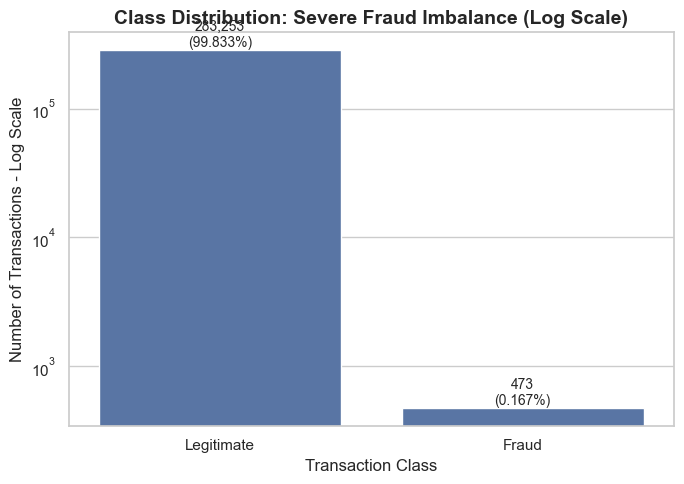

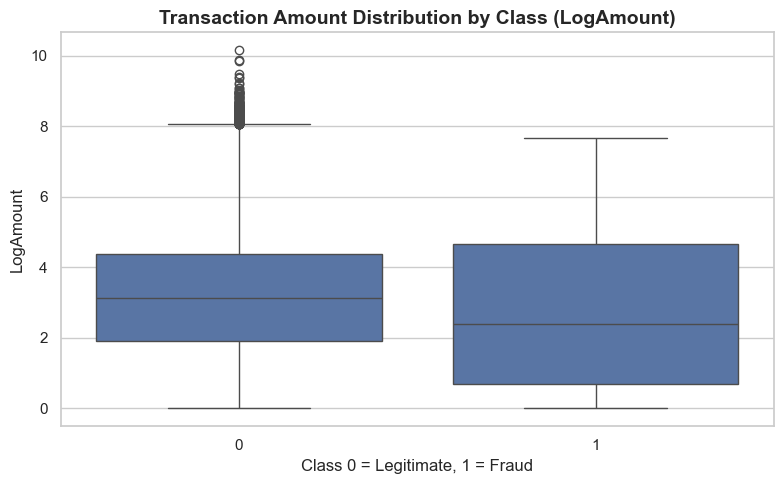

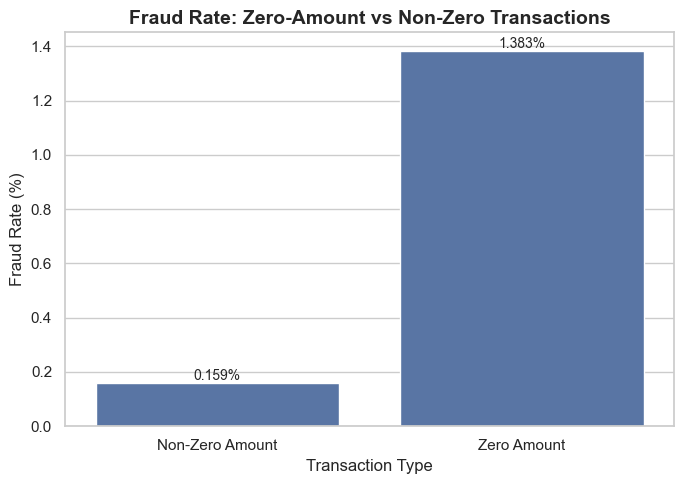

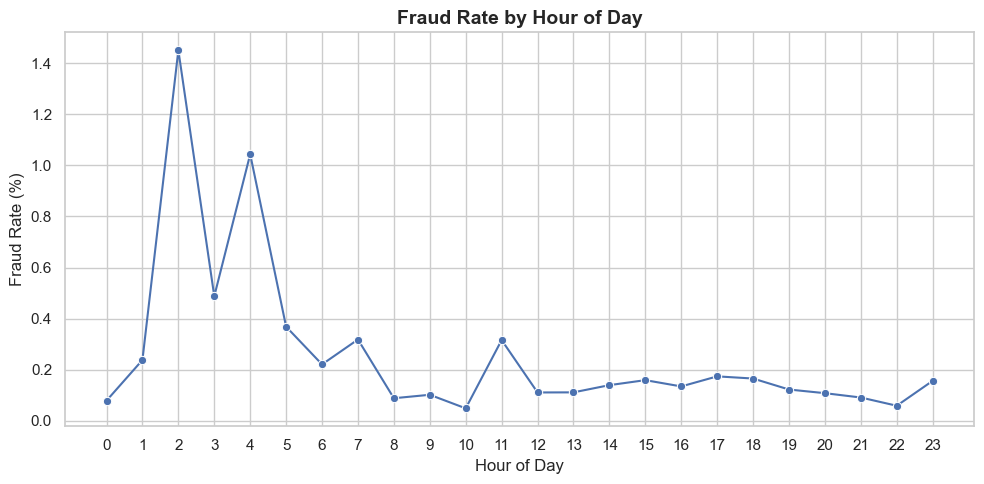

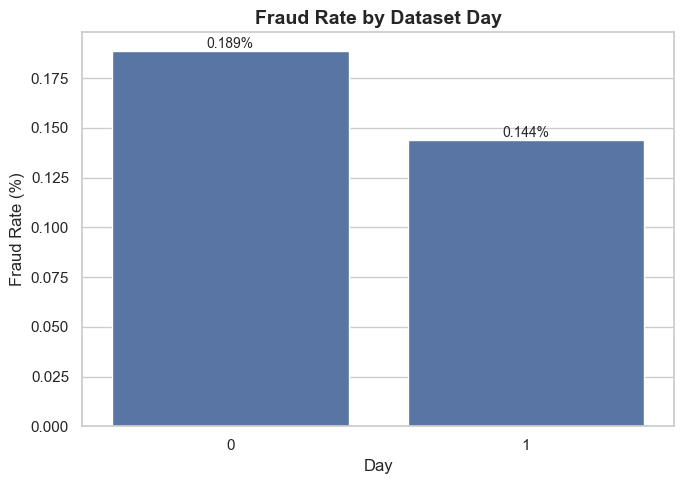

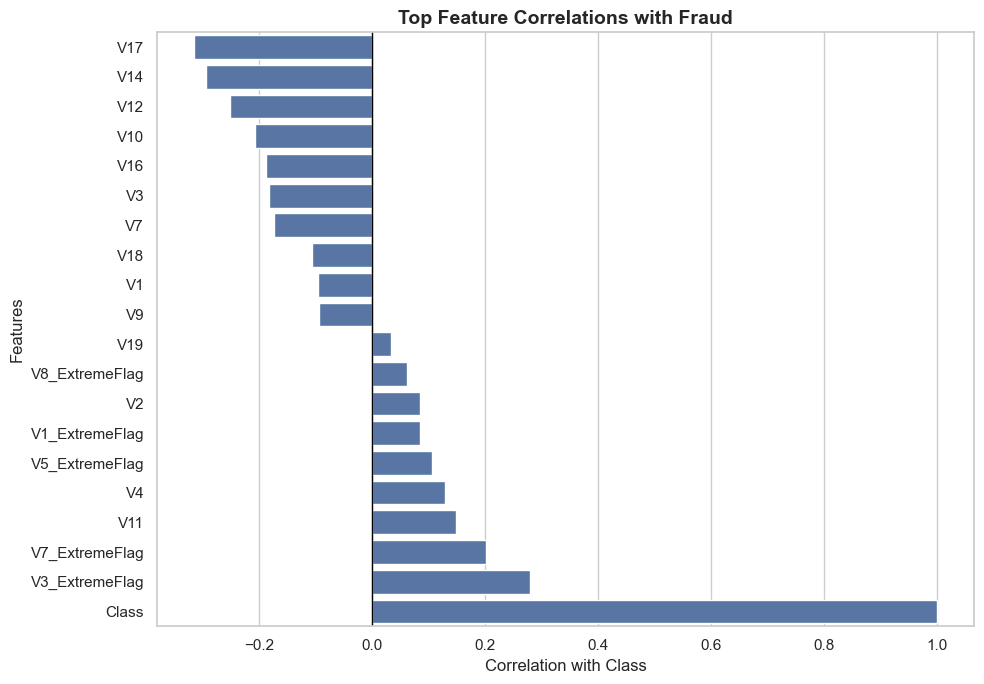

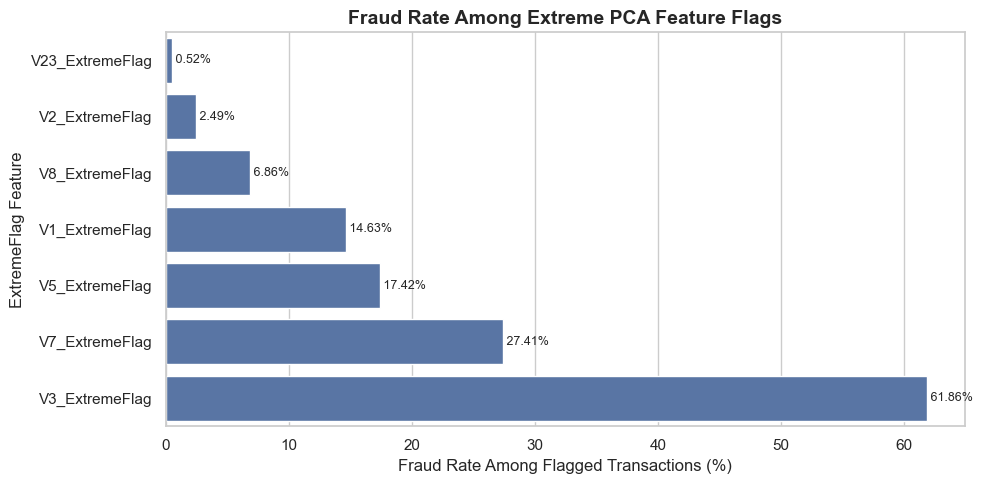

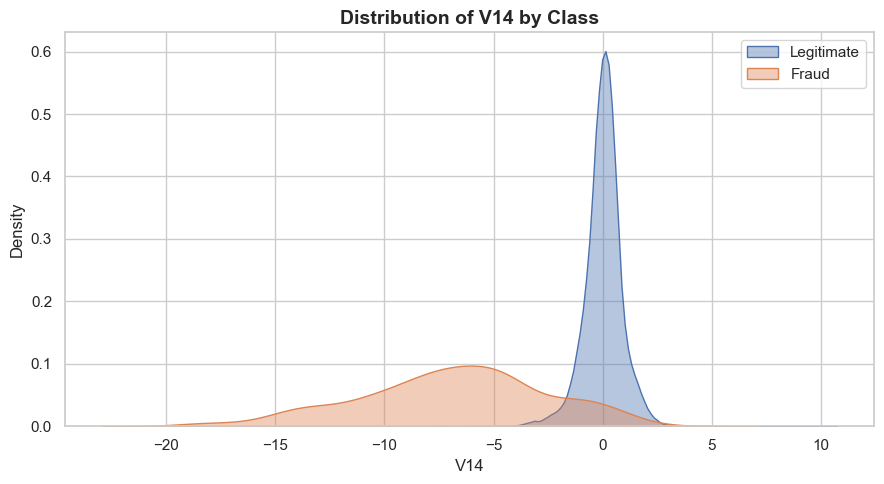

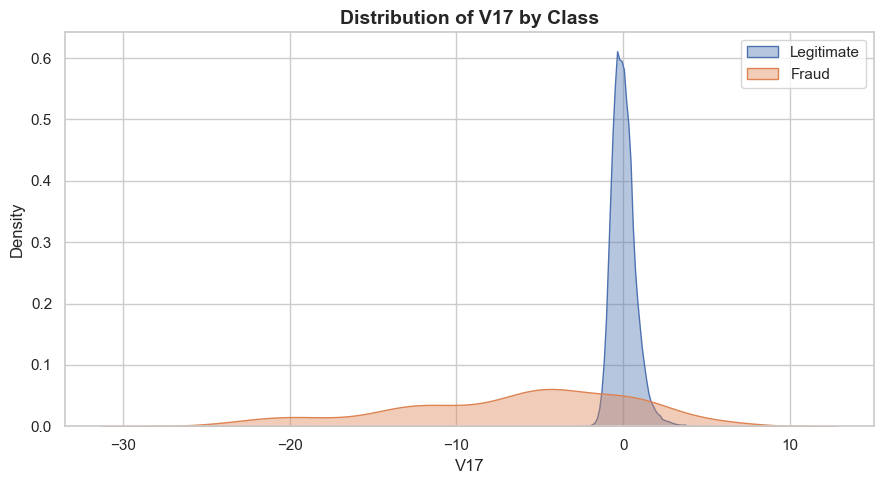

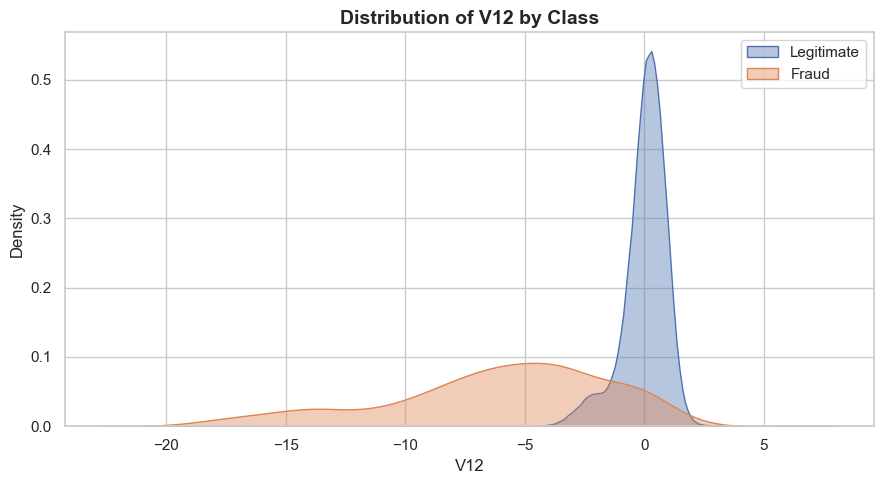

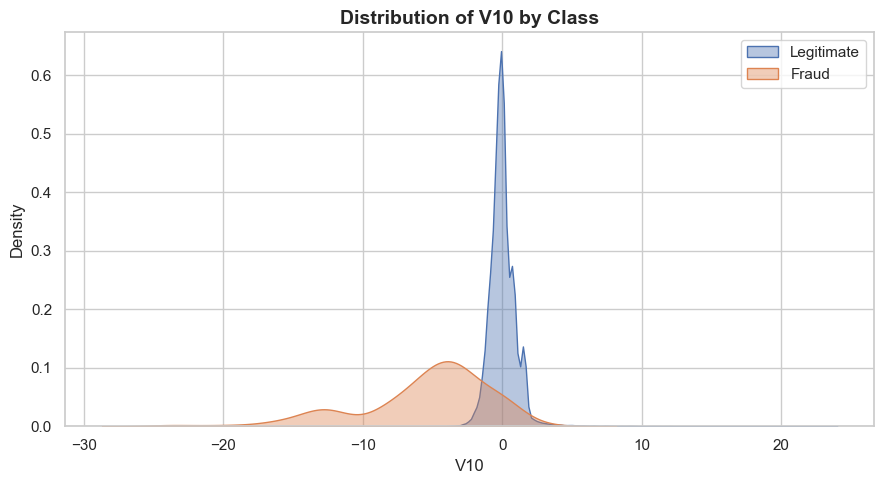

In [14]:
# =========================
# Important EDA Visuals for Fraud Detection
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# --------------------------------------------------
# 1. Class Distribution with Log Scale
# --------------------------------------------------

class_counts = df['Class'].value_counts().sort_index()
class_percent = df['Class'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=['Legitimate', 'Fraud'],
    y=class_counts.values
)

plt.yscale('log')

plt.title("Class Distribution: Severe Fraud Imbalance (Log Scale)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions - Log Scale")

for i, count in enumerate(class_counts.values):
    plt.text(
        i,
        count,
        f"{count:,}\n({class_percent.iloc[i]:.3f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 2. LogAmount Distribution by Class
# --------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='Class',
    y='LogAmount'
)

plt.title("Transaction Amount Distribution by Class (LogAmount)", fontsize=14, fontweight="bold")
plt.xlabel("Class 0 = Legitimate, 1 = Fraud")
plt.ylabel("LogAmount")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. Fraud Rate: Zero-Amount vs Non-Zero Transactions
# --------------------------------------------------
zero_fraud_rate = df.groupby('IsZeroAmount')['Class'].mean().mul(100)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=zero_fraud_rate.index.map({0: 'Non-Zero Amount', 1: 'Zero Amount'}),
    y=zero_fraud_rate.values
)

plt.title("Fraud Rate: Zero-Amount vs Non-Zero Transactions", fontsize=14, fontweight="bold")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Transaction Type")

for i, rate in enumerate(zero_fraud_rate.values):
    plt.text(i, rate, f"{rate:.3f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 4. Fraud Rate by Hour of Day
# --------------------------------------------------
hourly_fraud_rate = df.groupby('HourOfDay')['Class'].mean().mul(100)

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=hourly_fraud_rate.index,
    y=hourly_fraud_rate.values,
    marker='o'
)

plt.title("Fraud Rate by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 5. Fraud Rate by Dataset Day
# --------------------------------------------------
day_fraud_rate = df.groupby('Day')['Class'].mean().mul(100)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=day_fraud_rate.index,
    y=day_fraud_rate.values
)

plt.title("Fraud Rate by Dataset Day", fontsize=14, fontweight="bold")
plt.xlabel("Day")
plt.ylabel("Fraud Rate (%)")

for i, rate in enumerate(day_fraud_rate.values):
    plt.text(i, rate, f"{rate:.3f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 6. Top Positive and Negative Correlations with Fraud
# --------------------------------------------------
corr_with_target = df.corr(numeric_only=True)['Class'].sort_values()

top_negative = corr_with_target.head(10)
top_positive = corr_with_target.tail(10)

top_corr = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10, 7))
sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Feature Correlations with Fraud", fontsize=14, fontweight="bold")
plt.xlabel("Correlation with Class")
plt.ylabel("Features")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 7. Fraud Rate Among ExtremeFlag Features
# --------------------------------------------------
flag_cols = [col for col in df.columns if col.endswith('_ExtremeFlag')]

if len(flag_cols) > 0:
    flag_fraud_rates = {}

    for col in flag_cols:
        flagged_rows = df[df[col] == 1]
        if len(flagged_rows) > 0:
            flag_fraud_rates[col] = flagged_rows['Class'].mean() * 100

    flag_fraud_rates = pd.Series(flag_fraud_rates).sort_values()

    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=flag_fraud_rates.values,
        y=flag_fraud_rates.index
    )

    plt.title("Fraud Rate Among Extreme PCA Feature Flags", fontsize=14, fontweight="bold")
    plt.xlabel("Fraud Rate Among Flagged Transactions (%)")
    plt.ylabel("ExtremeFlag Feature")

    for i, rate in enumerate(flag_fraud_rates.values):
        plt.text(rate, i, f" {rate:.2f}%", va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("No ExtremeFlag features found.")


# --------------------------------------------------
# 8. KDE Plots for Strong Fraud-Related PCA Features
# --------------------------------------------------
important_pca_features = ['V14', 'V17', 'V12', 'V10']

for feature in important_pca_features:
    if feature in df.columns:
        plt.figure(figsize=(9, 5))

        sns.kdeplot(
            data=df[df['Class'] == 0],
            x=feature,
            label='Legitimate',
            fill=True,
            alpha=0.4
        )

        sns.kdeplot(
            data=df[df['Class'] == 1],
            x=feature,
            label='Fraud',
            fill=True,
            alpha=0.4
        )

        plt.title(f"Distribution of {feature} by Class", fontsize=14, fontweight="bold")
        plt.xlabel(feature)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

# Final Summary

## 1. Dataset Loading

- **284,807 rows**, **31 columns** loaded from `data/raw/creditcard.csv`
- `df_raw = df.copy()` saved as backup immediately after load
- Columns: `Time`, `V1–V28` (PCA-anonymized), `Amount`, `Class`
- Target: `0` = Legitimate, `1` = Fraud

---

## 2. Data Inspection

| Check | Result |
|-------|--------|
| Shape | (284,807 × 31) |
| Missing values | 0 |
| Duplicate rows | 1,081 |
| Non-numeric columns | None |
| Fraud rate | 0.173% — severely imbalanced |

Accuracy is a useless metric here. Use F1 Score and Precision-Recall AUC.

---

## 3. Data Cleaning

`df = df_raw.copy()` at the top makes the cell safe to re-run without corrupting state.

| Step | Finding | Action |
|------|---------|--------|
| Fraud duplicates | 19 fraud rows duplicated | Investigated — identical `Time` values confirm true duplicates, dropped |
| All duplicates | 1,081 rows | Removed via `drop_duplicates().reset_index()` |
| Missing values | 0 | None needed |
| Target dtype | Already `int64` | No cast needed |
| Negative Amount/Time | 0 | No action |
| Infinite values | 0 | Clean |
| Zero-amount rate | **1.38% fraud vs 0.17% baseline** | 8x elevated — kept, flagged in FE |

---

## 4. Outlier Investigation — V1-V28

PCA features should have std ≈ 1 and mean ≈ 0. Columns investigated for extreme sigma values:

| Column | Worst Sigma | Decision |
|--------|-------------|----------|
| V7 | ~97σ | Kept — flagged |
| V5 | ~82σ | Kept — flagged |
| V23 | ~72σ | Kept — flagged |
| V8 | ~61σ | Kept — flagged |
| V2 | ~44σ | Kept — flagged |
| V3 | ~32σ | Kept — flagged |
| V1 | ~29σ | Kept — flagged |

Extreme values are **not removed** — in fraud detection they are often the signal, not noise.
Instead, 7 binary `_ExtremeFlag` features are created (deterministic transforms, no data leakage).

---

## 5. Feature Engineering

| Feature | Source | Purpose |
|---------|--------|---------|
| `LogAmount` | `Amount` | Reduces right skew via `log(1+x)`, handles zero safely |
| `IsZeroAmount` | `Amount` | Flags ~8x fraud-risk zero-amount transactions |
| `Hour` | `Time` | Absolute hour 0–47 (intermediate, dropped before modeling) |
| `HourOfDay` | `Hour` | 0–23 daily cycle (intermediate, dropped before modeling) |
| `Day` | `Time` | Day 0 or Day 1 — fraud rate may differ |
| `HourSin` | `HourOfDay` | Cyclic encoding — hour 23 and hour 0 are adjacent |
| `HourCos` | `HourOfDay` | Cyclic encoding — complements HourSin |
| `V*_ExtremeFlag` ×7 | V1,V2,V3,V5,V7,V8,V23 | Binary outlier signal flags |

**RobustScaler** for `Amount` is deferred to after train-test split — fit on `X_train` only.

---

## 6. Final Dataset

| Metric | Value |
|--------|-------|
| Rows | 283,726 |
| Total columns | 45 (31 original + 14 engineered) |
| Fraud cases | 473 |
| Legitimate cases | 283,253 |

---

## 7. Recommended Feature Set

```python
drop_for_model = ['Class', 'Time', 'Amount', 'Hour', 'HourOfDay']
X = df[[col for col in df.columns if col not in drop_for_model]]
y = df['Class']
```

Keeps: `V1–V28`, `LogAmount`, `IsZeroAmount`, `Day`, `HourSin`, `HourCos`, 7× `_ExtremeFlag`

---

## 8. Next Steps

1. **Stratified train-test split** — preserve fraud ratio
2. **RobustScaler** — fit on `X_train`, transform both splits
3. **SMOTE or `class_weight`** — handle imbalance on training data only
4. **XGBoost** — primary model for imbalanced tabular fraud data
5. **SHAP** — post-model explainability
6. **LangChain RAG** — retrieve FATF/FinCEN regulations per fraud flag
7. **FastAPI + Streamlit** — production deployment
